# 线性回归

### 核心知识点：线性回归方程 (Vectorized Form)

为了计算方便，我们通常使用向量化形式来表示模型：

$$\hat{y} = h_{\mathbf{\theta}}(\mathbf{x}) = \mathbf{\theta} \cdot \mathbf{x}$$

- **$\mathbf{\theta}$**：模型的参数向量，包含偏置项 $\theta_0$ 和特征权重 $\theta_1$ 到 $\theta_n$。
- **$\mathbf{x}$**：特征向量，其中 $x_0$ 总是等于 1。
- **$\hat{y}$**：预测结果。

#### 成本函数 (MSE)
我们要找到一组 $\theta$，使得**均方误差 (Mean Squared Error)** 最小：
$$MSE(\mathbf{X}, h_{\theta}) = \frac{1}{m} \sum_{i=1}^{m} (\mathbf{\theta}^T \mathbf{x}^{(i)} - y^{(i)})^2$$

## 标准方程

---

### 1. 什么是标准方程？

为了让模型预测的误差（均方误差 MSE）最小，数学家们推导出了一个解析解。

**公式表达：**


$$\hat{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

* **$\hat{\theta}$**：使成本函数最小化的 $\theta$ 值。
* **$\mathbf{X}$**：特征矩阵。注意，为了计算偏置项 $\theta_0$，我们需要给 $\mathbf{X}$ 额外加上一列全为 1 的向量（即 $x_0 = 1$）。
* **$\mathbf{y}$**：目标值向量。
* **$T$**：矩阵转置。
* **$-1$**：矩阵的逆。

---

### 正规方程的优缺点

####  优点
1. **直接求解**：不需要设置学习率（Learning Rate）等超参数。
2. **一步到位**：不需要像梯度下降那样进行多次迭代。
3. **全局最优**：对于线性回归这种凸函数，它能保证找到全局最小值。

####  缺点
1. **计算复杂度高**：计算矩阵的逆的时间复杂度通常为 $O(n^{2.4})$ 到 $O(n^3)$。
2. **特征敏感**：当特征数量 $n$ 非常大（例如 $n = 100,000$）时，计算会变得极其缓慢。
3. **内存占用**：需要将整个数据集 $\mathbf{X}$ 加载到内存中。


---


生成一些线性数据来测试公式：

In [2]:
import numpy as np
from numpy.ma.core import minimum
from scipy.odr import polynomial
from tensorflow.python.ops.gen_control_flow_ops import next_iteration

X = 2*np.random.rand(100,1)
y = 4+3*X + np.random.randn(100,1)


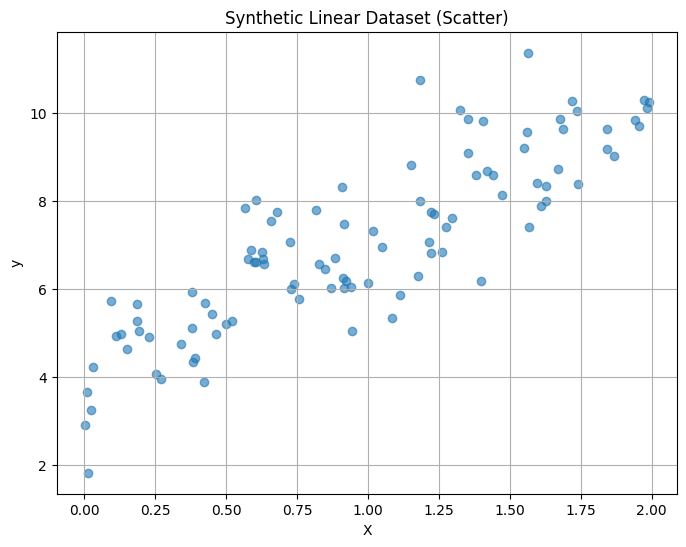

In [3]:
import matplotlib.pyplot as plt

# 绘制散点图
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.6)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Linear Dataset (Scatter)')
plt.grid(True)
plt.show()

使用标准方程计算$\hat{\theta}$

In [4]:
X_b = np.c_[np.ones((100,1)), X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [5]:
theta_best

array([[4.11152684],
       [3.01813129]])

我们可以用$\hat{\theta}$做出预测：

In [6]:
X_new = np.array([[0],[2]])
X_new_b = np.c_[np.ones((2,1)),X_new]
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 4.11152684],
       [10.14778942]])

绘制模型的预测结果：

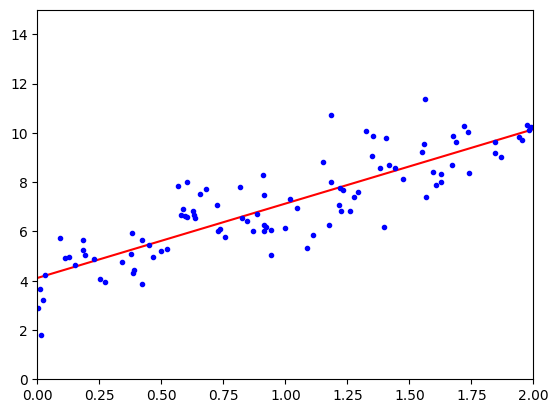

In [7]:
plt.plot(X_new, y_predict,'r-')
plt.plot(X,y,'b.')
plt.axis([0,2,0,15])
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)
lin_reg.intercept_, lin_reg.coef_

(array([4.11152684]), array([[3.01813129]]))

In [9]:
lin_reg.predict(X_new)

array([[ 4.11152684],
       [10.14778942]])

## 计算复杂度


---

### 1. 计算复杂度分析

在标准方程 $\hat{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$ 中：

* **特征维度 ($n$) 的挑战**：
计算 $(\mathbf{X}^T \mathbf{X})^{-1}$ 需要对一个 $n \times n$ 的矩阵求逆。在计算机科学中，矩阵求逆的计算复杂度通常在 $O(n^{2.4})$ 到 $O(n^3)$ 之间。
* **直观理解**：这意味着如果你将特征数量（例如从 $100$ 增加到 $1,000$）翻 **10 倍**，计算时间可能会增加大约 $10^3 = \mathbf{1000}$ **倍**。


* **样本数量 ($m$) 的挑战**：
计算 $\mathbf{X}^T \mathbf{X}$ 的复杂度是 $O(n^2 m)$。
* **直观理解**：它对样本量是**线性**相关的。如果你有 1 亿行数据，计算会变慢，但只要特征数 $n$ 很少，内存还能撑得住。



---

### 2. 预测复杂度（Prediction Complexity）

一旦模型训练完成（拿到了 $\hat{\theta}$），预测的效率是极高的：

* **复杂度**：$O(n)$。
* **直观理解**：预测只需要做一次向量点积。无论你训练时用了多久，预测新数据几乎是瞬时的。

---


# 梯度下降

### 梯度下降 (Gradient Descent)

#### 1. 梯度的计算
对于线性回归，成本函数 MSE 的梯度向量为：
$$\nabla_{\theta} MSE(\theta) = \frac{2}{m} \mathbf{X}^T (\mathbf{X} \theta - \mathbf{y})$$
注意：这里依然有 $\mathbf{X}^T$ 运算，但不需要求逆，计算量远小于标准方程。

#### 2. 特征缩放 (Feature Scaling) 的必要性
- **重要！** 如果特征之间的量纲差异巨大（如：房龄 0~20 年，面积 0~200 平米），
  误差曲面会变成一个极其细长的“深谷”。
- 梯度下降在细长深谷里会左右横跳，很难下到谷底。
- **结论**：在使用梯度下降前，务必使用 `StandardScaler` 进行标准化。

---

###  梯度下降的执行步骤

在机器学习中，梯度下降是一个不断迭代的过程，通常遵循以下四个核心步骤：

### 梯度下降 (Gradient Descent) 的执行流程

1. **初始化参数**：
   - 随机给 $\theta$ 设置一个初始值（比如全 0 或随机小数）。这时模型处于最原始的状态，预测误差通常很大。

2. **计算损失函数的梯度**：
   - 在当前 $\theta$ 的位置，计算成本函数（如 MSE）相对于每个参数的导数（即梯度）。
   - **直观理解**：这相当于在山坡上感受脚下的坡度，确定哪个方向下山最快。

3. **更新参数**：
   - 沿着梯度的**反方向**更新 $\theta$。更新幅度由**学习率（$\eta$）**决定。
   - 公式：$\theta^{(next)} = \theta - \eta \cdot \nabla_{\theta} J(\theta)$

4. **判断收敛**：
   - 重复步骤 2 和 3，直到梯度变得非常小（接近 0），或者达到了预设的迭代次数。
   - 这时，模型已经找到了（或非常接近）让误差最小的最优参数。


---

###  学习率（步长）选取的影响

学习率 $\eta$ 是梯度下降中最重要的超参数。它决定了你“下山”的步子有多大，不同的选取会导致完全不同的后果：

#### 1. 学习率太小（步长太碎）

* **后果**：模型会非常小心翼翼地移动。
* **表现**：训练速度极其缓慢，需要大量的迭代才能到达谷底。
* **风险**：如果计算资源有限，可能在还没收敛到最优解时就耗尽了时间。

#### 2. 学习率太大（步太大）

* **后果**：模型在山谷两侧疯狂横跳。
* **表现**：算法可能跨过最低点，导致误差不降反升。
* **风险**：**发散**。误差会越来越大，最终程序报错或得不到任何有效结果。

#### 3. 学习率适中（完美状态）

* **后果**：模型能够平稳且快速地降落到谷底。
* **表现**：损失曲线（Learning Curve）呈平滑下降趋势，并最终稳定。

---


## 批量梯度下降

---

### 1. 批量梯度下降的数学推导

要实现这个算法，我们首先需要知道成本函数（MSE）关于每一个参数 $\theta_j$ 的导数。

**偏导数公式：**
对于每一个参数 $\theta_j$，我们需要计算它对误差的影响：


$$\frac{\partial}{\partial \theta_j} MSE(\theta) = \frac{2}{m} \sum_{i=1}^{m} (\theta^T \mathbf{x}^{(i)} - y^{(i)}) x_j^{(i)}$$

**向量化梯度公式：**
为了让代码运行得飞快，我们不会一个一个去算偏导数，而是利用矩阵运算一次性算出所有 $\theta$ 的梯度：


$$\nabla_{\theta} MSE(\theta) = \frac{2}{m} \mathbf{X}^T (\mathbf{X} \theta - \mathbf{y})$$

---

### 2. 批量梯度下降的执行过程


### 核心笔记：批量梯度下降 (Batch GD)

#### 算法流程
1. **全量计算**：在每一次迭代中，算法都会遍历**所有的** $m$ 条训练数据来计算梯度。
2. **参数更新**：使用算出的平均梯度乘以学习率 $\eta$，更新当前的参数向量 $\theta$。
3. **循环往复**：重复上述过程，直到达到预设的迭代次数或梯度变得极小。

####  优缺点分析
- **优点**：
    - **路径平稳**：由于每次都参考了所有数据，参数更新的方向非常准确，轨迹是一条笔直指向最小值的直线。
    - **理论完美**：对于凸函数（如线性回归），它一定能收敛到全局最小值。
- **缺点**：
    - **内存压力大**：如果数据集有 1 亿行，每一小步都要计算 1 亿行的矩阵乘法，计算极其缓慢。
    - **不可在线学习**：无法在训练过程中实时加入新数据。


---



#### 1. 梯度计算 (Gradient Calculation)
在每一步迭代中，我们计算整个训练集的梯度向量：
$$\nabla_{\theta} MSE(\theta) = \frac{2}{m} \mathbf{X}^T (\mathbf{X} \theta - \mathbf{y})$$
- 该公式计算了成本函数在当前位置最陡峭的“坡度”。

#### 2. 参数更新 (Step Update)
一旦有了梯度，我们就向梯度的**反方向**迈出一小步：
$$\theta^{(next step)} = \theta - \eta \cdot \nabla_{\theta} MSE(\theta)$$
- $\eta$ (Learning Rate) 决定了步子的大小。

#### 3. 算法特性
- **计算成本**：由于每一步都要计算完整的 $\mathbf{X}^T \mathbf{X}$ 相关运算，当 $m$ (样本量) 巨大时，计算会非常缓慢。
- **内存需求**：需要将整个数据集一次性放入内存，对大内存依赖较高。
- **收敛性**：轨迹平滑，能够稳步逼近全局最小值。

In [10]:
eta = 0.1 # 学习率
n_iterations = 1000
m = 100

theta = np.random.randn(2,1)

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

In [11]:
theta

array([[4.11152684],
       [3.01813129]])

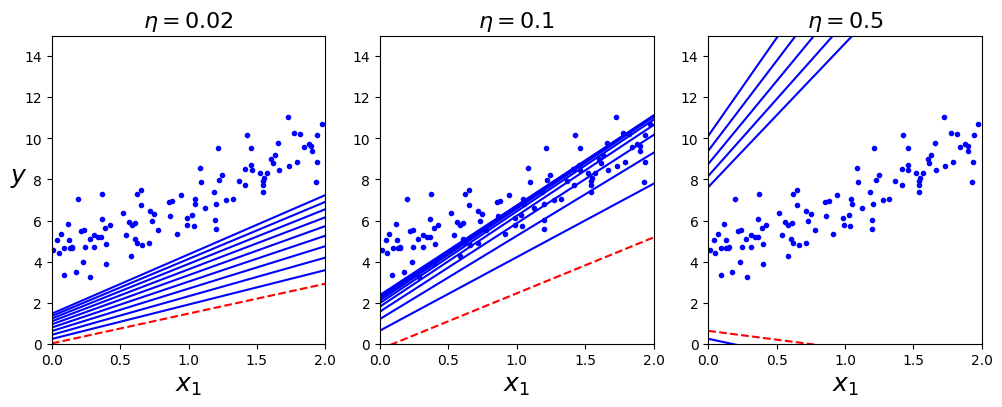

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 准备数据 (与之前生成的散点数据保持一致)
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)
X_b = np.c_[np.ones((100, 1)), X]  # 添加偏置项 x0 = 1

# 2. 定义绘图函数
def plot_gradient_descent(theta, eta, theta_path=None):
    m = len(X_b)
    plt.plot(X, y, "b.") # 绘制蓝色原始散点
    n_iterations = 1000
    for iteration in range(n_iterations):
        if iteration < 10: # 只绘制前 10 步的预测线
            y_predict = X_new_b.dot(theta)
            style = "b-" if iteration > 0 else "r--" # 初始线为红色虚线，后续为蓝色实线
            plt.plot(X_new, y_predict, style)

        # 梯度下降核心公式
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
        if theta_path is not None:
            theta_path.append(theta)

    plt.xlabel("$x_1$", fontsize=18)
    plt.axis([0, 2, 0, 15])
    plt.title(r"$\eta = {}$".format(eta), fontsize=16)

# 3. 准备预测用的新点 (0 和 2)
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]

# 4. 绘制对比图
plt.figure(figsize=(12, 4))

# 学习率太低
plt.subplot(131); plot_gradient_descent(np.random.randn(2,1), eta=0.02)
plt.ylabel("$y$", rotation=0, fontsize=18)

# 学习率理想
plt.subplot(132); plot_gradient_descent(np.random.randn(2,1), eta=0.1)

# 学习率太高
plt.subplot(133); plot_gradient_descent(np.random.randn(2,1), eta=0.5)

plt.show()

### 学习率 $\eta$ 对收敛的影响

观察绘制出的三幅图，我们可以得出以下结论：

1. **$\eta = 0.02$ (左图：太小)**：
   - **现象**：直线移动非常缓慢。
   - **结论**：算法最终能找到最优解，但需要极长的迭代时间。如果迭代次数不够，模型将处于欠拟合状态。

2. **$\eta = 0.1$ (中图：理想)**：
   - **现象**：仅仅经过几次迭代，直线就迅速重合到了数据中心位置。
   - **结论**：这是最理想的状态，算法收敛速度快且稳定。

3. **$\eta = 0.5$ (右图：太大)**：
   - **现象**：第一步（虚线到第一条实线）就直接跳过了数据区域，后续直线在顶部乱跳。
   - **结论**：算法**发散 (Diverge)**，它在不断跳过最优解并离目标越来越远，最终会导致计算溢出（NaN）。


---
有两种限制迭代次数的方法
### 1. 设置一个很大的迭代次数 + 容差（Tolerance）

这是最常用且智能的方法。与其死板地设置循环 1000 次，不如给算法一个“及格线”。

* **逻辑**：预设一个非常大的迭代次数（比如 10,000 次），同时定义一个极小的数字 $\epsilon$（称为 **容差**，例如 $10^{-7}$）。
* **操作**：在每一步迭代后，计算梯度向量的**范数（长度）**。
* **停止条件**：当梯度的模小于 $\epsilon$ 时，说明坡度已经极其平缓，模型已经非常接近最小值了，此时**提前停止**迭代。

---

### 2. 学习率调度（Learning Schedule）

虽然这在**随机梯度下降（SGD）**中更常见，但在批量梯度下降中也可以借鉴这种思想来“变相”限制无效迭代。

* **初始阶段**：使用较大的步长，快速冲向谷底，避免在平缓区域磨蹭。
* **后期阶段**：随着迭代次数增加，自动减小步长，让模型在最小值附近“精确着陆”，而不是反复震荡。

---


### 如何控制迭代次数

####  为什么不能只靠固定次数？
- 如果学习率 $\eta$ 很小，固定的 1000 次可能远远不够。
- 如果 $\eta$ 较大，可能 50 次就收敛了，剩下的 950 次是在浪费 CPU。

####  收敛速率

* 对于批量梯度下降，当成本函数是凸函数（如线性回归）时，具有 **$O(1/iterations)$** 的收敛率。
* **直观理解**：如果你想要把误差缩小到原来的 1/10（即增加一位精度），你通常需要将迭代次数增加 10 倍。

---


### 收敛率 (Convergence Rate)

1. **基本规律**：
   批量梯度下降在处理凸函数时，误差下降速度遵循 $O(1/iterations)$。

2. **精度代价**：
   如果希望将模型预测的精度提升 1 位（即误差从 0.01 降到 0.001），
   可能需要多跑 10 倍的迭代次数。

3. **算法对比**：
   - **批量梯度下降**：收敛路径稳定，方向准确，但每步计算量大 ($O(m \cdot n)$)。
   - **随机梯度下降 (SGD)**：虽然收敛路径震荡，但每步计算极快，通常能更快地接近最小值区域。

## 随机梯度下降


### 1. 核心原理：每次只看一个样本


* **操作**：在每一步迭代中，它只随机选择**一个**样本来计算梯度并更新参数。
* **代价**：由于只参考一个样本，它得到的梯度方向可能并不完全指向最小值（甚至可能跑偏）。
* **结果**：参数会像“醉汉”一样，在通往最小值的路上疯狂震荡，而不是平滑地降落。

---

### 2. 为什么需要 SGD？（优缺点分析）


| 特性 | 批量梯度下降 (Batch GD) | 随机梯度下降 (SGD) |
| --- | --- | --- |
| **计算量** | 极大（每步遍历所有 $m$ 个样本） | 极小（每步只看 1 个样本） |
| **内存需求** | 必须将全量数据载入内存 | 每次只需载入 1 条数据，适合超大规模数据 |
| **收敛路径** | 平滑、直接 | 震荡、跳跃 |
| **局部最小值** | 容易陷入局部最优（如果是复杂函数） | **优势**：跳跃性有助于跳出局部最优解 |

---

### 3. 学习率调度：

由于 SGD 永远在跳跃，它即使到了最小值附近也不会停下来，而是会一直绕着最小值打转。为了让它最终停在谷底，我们需要使用**学习率调度 (Learning Schedule)**。

* **策略**：开始时让步子大一点（快速接近目标），随着时间推移让步子越来越小（精确定位）。
* **术语**：确定每步学习率的函数被称为**学习计划 (Learning Schedule)**。

---


In [13]:
n_epochs = 50
t0,t1 = 5,50

def learning_schedule(t):
    return t0/(t+t1)
theta = np.random.randn(2,1)

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2*xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch*m+1)
        theta = theta - eta * gradients

In [14]:
theta

array([[4.18822928],
       [2.7298745 ]])

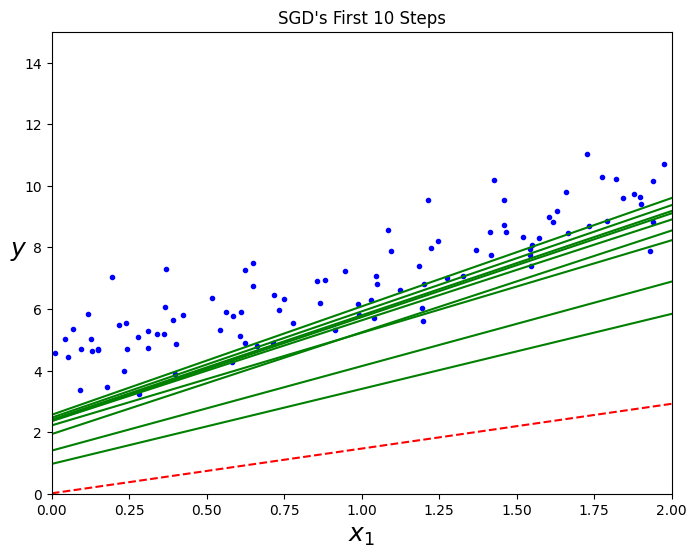

最终训练得到的参数 theta:
[[4.19000137]
 [2.73381258]]


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 准备数据 (保持与书中的随机种子一致，确保复现)
np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)
X_b = np.c_[np.ones((m, 1)), X]  # 添加偏置项 x0 = 1

# 2. 定义学习计划 (Learning Schedule)
t0, t1 = 5, 50
def learning_schedule(t):
    return t0 / (t + t1)

# 3. 初始化参数
theta = np.random.randn(2, 1)
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]

# 4. 绘图并执行 SGD
plt.figure(figsize=(8, 6))
plt.plot(X, y, "b.") # 绘制原始数据点

n_epochs = 50
for epoch in range(n_epochs):
    for i in range(m):
        # 仅在第一轮的前 10 步绘制直线
        if epoch == 0 and i < 10:
            y_predict = X_new_b.dot(theta)
            style = "r--" if i == 0 else "g-" # 第一条线为红色虚线，其余为绿色实线
            plt.plot(X_new, y_predict, style)

        # 随机选择一个样本 (SGD 核心)
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]

        # 计算该样本的梯度并更新
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

# 5. 图形修饰
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.title("SGD's First 10 Steps")
plt.show()

print(f"最终训练得到的参数 theta:\n{theta}")

In [17]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=50,penalty = None,eta0=0.1)
sgd_reg.fit(X,y.ravel())

,loss,'squared_error'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,50
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [18]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.1668084]), array([2.70107103]))

## 小批量梯度下降

---

### 1. 核心原理：每次看一小撮数据

小批量梯度下降不再是看 1 个或者全部样本，而是每次迭代计算一小组样本（称为一个 **Mini-batch**）的梯度。

* **Batch Size（批大小）**：通常设置为 10 到 1000 之间的 2 的幂次方（如 32, 64, 128）。
* **更新方式**：计算这几十个样本的平均梯度，然后更新 $\theta$。

---

### 2.优势

相比于前两种算法，小批量梯度下降拥有独特的优势：

* **硬件加速（GPU）**：现代计算机的矩阵运算指令集（以及 GPU）对大小适中的矩阵运算进行了高度优化。一次处理 32 个样本往往比循环处理 1 个样本快得多。
* **路径更稳定**：比起 SGD 的“乱撞”，Mini-batch 的路径更平滑，更容易收敛到最小值区域。
* **内存友好**：不需要像批量梯度下降那样一次载入几百万条数据，只需要载入一个小 Batch，这让它能处理超大规模数据集。

---

###  知识点笔记：三种梯度下降路径对比

### 📉 算法路径对比 (Trajectory Comparison)

1. **批量 (Batch GD)**：路径最稳，直接指向终点，但每一步都非常沉重（慢）。
2. **随机 (SGD)**：路径最乱，像醉汉一样乱跳，但每一步都非常轻快（快）。
3. **小批量 (Mini-batch GD)**：路径介于两者之间，有一定的震荡，但整体趋势明确，且能利用硬件并行计算优势。

> **结论**：在深度学习和处理大数据时，小批量梯度下降几乎是默认首选。

---


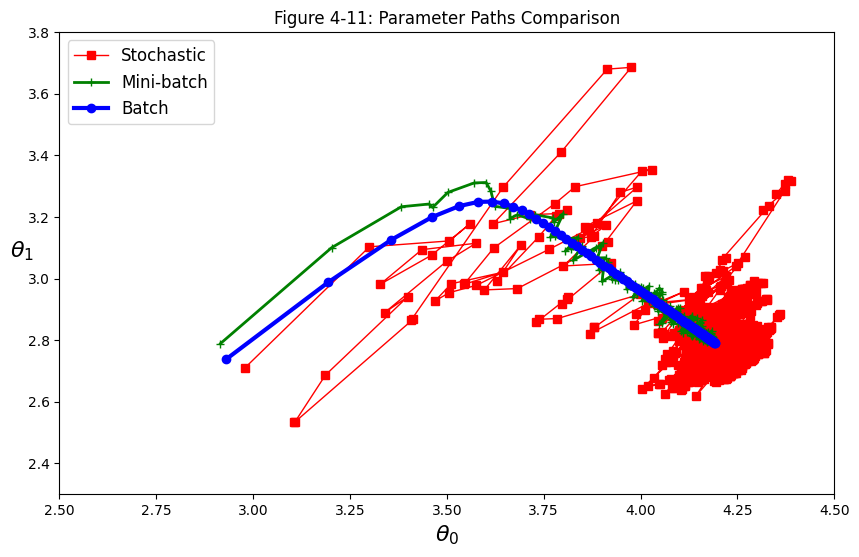

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 数据准备 ---
np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)
X_b = np.c_[np.ones((m, 1)), X]

# 初始化保存路径的列表
theta_path_bgd = []
theta_path_sgd = []
theta_path_mgd = []

# --- 2. 批量梯度下降 (Batch GD) ---
theta = np.array([[2.5], [2.3]]) # 统一初始起点
eta = 0.1
for iteration in range(100):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients
    theta_path_bgd.append(theta)

# --- 3. 随机梯度下降 (SGD) ---
theta = np.array([[2.5], [2.3]])
t0, t1 = 5, 50
def learning_schedule(t):
    return t0 / (t + t1)

t = 0
for epoch in range(50):
    for i in range(m):
        t += 1
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(t)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)

# --- 4. 小批量梯度下降 (Mini-batch GD) ---
theta = np.array([[2.5], [2.3]])
minibatch_size = 20
t = 0
for epoch in range(50):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for i in range(0, m, minibatch_size):
        t += 1
        xi = X_b_shuffled[i:i+minibatch_size]
        yi = y_shuffled[i:i+minibatch_size]
        gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(t)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

# --- 5. 绘图 ---
theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

plt.figure(figsize=(10, 6))
plt.plot(theta_path_sgd[:, 0], theta_path_sgd[:, 1], "r-s", linewidth=1, label="Stochastic")
plt.plot(theta_path_mgd[:, 0], theta_path_mgd[:, 1], "g-+", linewidth=2, label="Mini-batch")
plt.plot(theta_path_bgd[:, 0], theta_path_bgd[:, 1], "b-o", linewidth=3, label="Batch")

plt.legend(loc="upper left", fontsize=12)
plt.xlabel(r"$\theta_0$", fontsize=16)
plt.ylabel(r"$\theta_1$", rotation=0, fontsize=16)
plt.axis([2.5, 4.5, 2.3, 3.8]) # 设置坐标轴范围与书中一致
plt.title("Figure 4-11: Parameter Paths Comparison")
plt.show()


---

### 线性回归算法比较

| 算法 | $m$ 很大时 | 是否支持核外 | $n$ 很大时 | 超参数 | 是否需要缩放 | Scikit-Learn |
| --- | --- | --- | --- | --- | --- | --- |
| **标准方程** | 快 | 否 | 慢 | 0 | 否 | `LinearRegression` |
| **批量 GD** | 慢 | 否 | 快 | 2 | **是** | n/a |
| **随机 GD** | 快 | **是** | 快 | $\ge 2$ | **是** | `SGDRegressor` |
| **小批量 GD** | 快 | **是** | 快 | $\ge 2$ | **是** | n/a |

---

### 核心观察

* **路径形状**：Batch GD 路径最稳，直接奔向最小值；SGD 路径最乱，在最小值附近不断跳跃；Mini-batch GD 则介于两者之间，比随机更稳，但比批量更灵活。
* **核外支持 (Out-of-core)**：SGD 和小批量 GD 可以处理不适合装进单机内存的大规模数据集，因为它们一次只需要处理一小部分样本。
* **最终效果**：尽管过程不同，但如果设置好学习计划，这三种算法最后生成的模型效果几乎没有差别。


## 多项式回归

### 核心笔记：多项式回归

- **本质**：多项式回归依然是“线性回归”，因为模型参数 $\theta$ 与特征之间是线性关系。我们只是改变了特征的形式。
- **优点**：能够拟合复杂的曲线数据，捕捉特征间的交互。
- **缺点**：阶数 (Degree) 过高时极易导致**过拟合 (Overfitting)**。

In [20]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2,include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([0.74908024])

In [21]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.56140272]), array([[1.63887939, 0.5810637 ]]))

## 学习曲线

**学习曲线（Learning Curves）** 就是用来诊断模型是处于**欠拟合（Underfitting）**还是**过拟合（Overfitting）**状态的工具。

---

### 1. 什么是学习曲线？

学习曲线是以**训练集大小**为横轴，以**误差（通常是 RMSE）**为纵轴的图表。它展示了随着训练样本数量的增加，模型在**训练集**和**验证集**上的表现演变过程。

---

### 2. 如何通过曲线诊断模型？

#### 情况 A：欠拟合（Underfitting）

如果模型过于简单（例如用直线拟合二次曲线）：

* **训练误差**：随着样本增加，误差迅速上升并达到一个**平台（Plateau）**。这是因为简单的模型无法捕捉数据的非线性特征，再多数据也没用。
* **验证误差**：与训练误差非常接近，且都处于较高的水平。
* **结论**：如果两条曲线都已到达平台且位置很高，增加更多训练数据通常**无济于事**，需要更复杂的模型。

#### 情况 B：过拟合（Overfitting）

如果模型过于复杂（例如用 100 阶多项式拟合）：

* **训练误差**：始终保持在较低水平。模型由于太复杂，甚至记住了噪声，因此在训练集上表现极好。
* **验证误差**：明显高于训练误差。
* **差距（Gap）**：两条曲线之间存在巨大的间隙，这是过拟合的显著标志。
* **结论**：此时**增加更多训练数据**会有所帮助，因为数据量越大，模型越难拟合到每一个噪声点，两条曲线会逐渐接近。

---

#### 偏差与方差的权衡

学习曲线本质上是在展示模型的**偏差（Bias）**与**方差（Variance）**：

* **高偏差**：模型太简单（欠拟合），学习曲线最终会靠在一起，但误差很大。
* **高方差**：模型太复杂（过拟合），学习曲线之间有很大的间隙。


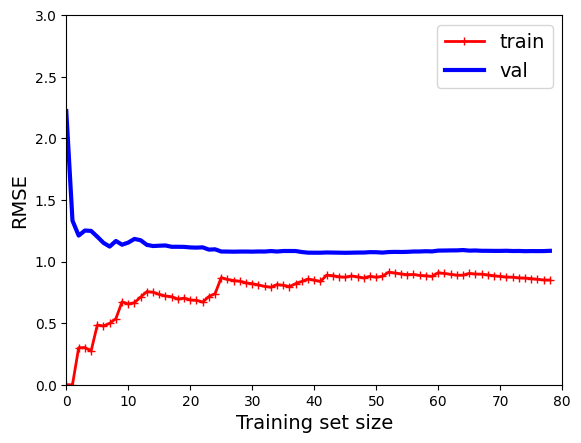

In [22]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=10)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))

    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
    plt.legend(loc="upper right", fontsize=14)
    plt.xlabel("Training set size", fontsize=14)
    plt.ylabel("RMSE", fontsize=14)

# 尝试绘制线性模型的学习曲线
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)
plt.axis([0, 80, 0, 3])
plt.show()

接下来看看十阶多项式模型的学习曲线

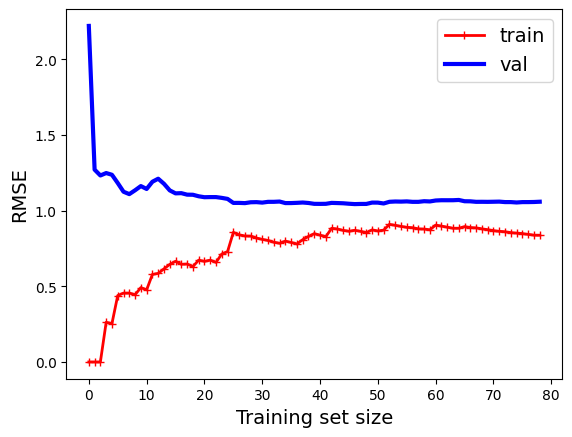

In [24]:
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline((
    ('poly_features', PolynomialFeatures(degree=2,include_bias=False)),
    ('sgd_reg',LinearRegression()),
))
plot_learning_curves(polynomial_regression, X, y)

# 正则线性模型


**岭回归（Ridge Regression）**，也称为 Tikhonov 正则化，是线性回归的一种正则化版本。

---

### 1. 核心原理：

在普通的线性回归中，我们只关心如何最小化均方误差（MSE）。而在岭回归中，我们在成本函数中添加了一个**正则项（也叫惩罚项）**：

#### 岭回归成本函数：

$$J(\theta) = MSE(\theta) + \alpha \frac{1}{2} \sum_{i=1}^{n} \theta_i^2$$

* **正则项 $\alpha \frac{1}{2} \sum \theta_i^2$**：它强制算法不仅要拟合数据，还要保持模型参数 $\theta$ 尽可能小。
* **超参数 $\alpha$**：控制拟合数据与保持参数简单之间的平衡。
* 如果 $\alpha = 0$，岭回归就变成了普通的线性回归。
* 如果 $\alpha$ 非常大，所有权重都会非常接近于零，结果就是一条穿过数据平均值的水平直线。

---

### 2. 为什么要使用岭回归？

* **对抗过拟合**：通过约束参数的大小，模型对噪声的敏感度降低，泛化能力更强。
* **数值稳定性**：在某些特征高度相关（多重共线性）的情况下，普通线性回归的矩阵求逆可能会变得不稳定，而岭回归通过引入正则项解决了这个问题。

---

### 3. 代码实现：Scikit-Learn 中的岭回归

可以直接使用 `Ridge` 类来实现。注意：在进行正则化之前，**务必进行特征缩放（Feature Scaling）**，因为正则化对特征的量纲非常敏感。


---

### 注意事项

* **只在训练时使用**：正则项只应在**训练期间**添加到成本函数中。一旦模型训练完成，评估模型性能（在测试集或验证集上）应使用未经正则化的指标（如原始 MSE）。
* **偏差与方差**：使用岭回归会增加模型的**偏差（Bias）**，但会显著降低其**方差（Variance）**。



---

### 1. 岭回归的闭式解公式

岭回归的成本函数在加入 $L_2$ 正则项后，其最优解的数学表达式为：

$$\hat{\theta} = (\mathbf{X}^T \mathbf{X} + \alpha \mathbf{A})^{-1} \mathbf{X}^T \mathbf{y}$$

* **$\mathbf{A}$**：这是一个 $(n+1) \times (n+1)$ 的单位矩阵，但左上角的元素为 0（对应偏置项 $\theta_0$，因为通常不对偏置项进行正则化）。
* **$\alpha \mathbf{A}$**：这就是正则化项在矩阵运算中的体现。

---

### 2. 为什么闭式解比普通标准方程更“稳”？

普通线性回归的标准方程是 $\hat{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$。

* **解决不可逆问题**：如果特征之间存在高度相关性（多重共线性），$\mathbf{X}^T \mathbf{X}$ 可能是奇异矩阵（不可逆）。
* **强制可逆**：在岭回归公式中，加上 $\alpha \mathbf{A}$ 就像是在矩阵的对角线上加上了一个小值，这能确保得到的矩阵**一定可逆**。这也是为什么岭回归在数值计算上比普通回归更稳定的原因。

---

---

### 闭式解 vs 梯度下降

可以根据这张表来决定在你的 Notebook 里使用哪种方式：

| 维度 | 闭式解 (`Ridge(solver="cholesky")`) | 梯度下降 (`SGDRegressor(penalty="l2")`) |
| --- | --- | --- |
| **计算方式** | 一步到位（矩阵运算） | 逐步迭代（搜索） |
| **数据规模** | 适合特征数 $n$ 较小的情况 | 适合海量样本 $m$ 和特征 $n$ |
| **内存占用** | 需要将整个矩阵放入内存 | 内存占用低，支持核外计算 |

---


In [25]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1,solver='cholesky')
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([8.32725833])

## Lasso回归

**套索回归（Lasso Regression）**，全称是“最小绝对收缩和选择算子”（Least Absolute Shrinkage and Selection Operator），是线性回归的另一种正则化版本。

它与岭回归非常相似，但在惩罚方式上有一个关键的数学差异，这导致了完全不同的物理行为。

---

### 1. 核心原理：$L_1$ 范数惩罚

套索回归在成本函数中添加的是权重向量的 **$L_1$ 范数**（即绝对值之和），而不是平方和。

#### 套索回归成本函数：

$$J(\theta) = MSE(\theta) + \alpha \sum_{i=1}^{n} |\theta_i|$$

* **$\alpha$ 的作用**：同样是控制正则化的强度。
* **稀疏性（Sparsity）**：这是 Lasso 最重要的特性。它倾向于完全消除最不重要特征的权重，即直接将它们设为 **0**。

---

### 2. Lasso 的“自动特征选择”功能

由于 Lasso 会将无用特征的系数变为 0，它实际上是在训练过程中自动执行了**特征选择（Feature Selection）**。

* **产出结果**：你会得到一个**稀疏模型**，其中只有少数特征的系数不为零。
* **适用场景**：当你怀疑数据集中只有一小部分特征是真正起作用的时候，Lasso 非常有用。

---

### 3. 代码实现：Scikit-Learn 中的 Lasso
可以直接调用 `Lasso` 类。同样提醒：使用正则化模型前必须进行**特征缩放**。

---

### 岭回归 vs 套索回归


| 特性 | 岭回归 (Ridge / $L_2$) | 套索回归 (Lasso / $L_1$) |
| --- | --- | --- |
| **权重缩减** | 均匀缩小，但不会减到 0 | 倾向于将不重要权重减为 0 |
| **模型复杂度** | 保留所有特征（密集模型） | 自动选择特征（稀疏模型） |
| **计算特性** | 在原点处是可微的 | 在 $\theta_i=0$ 处不可微（需使用次梯度） |

---

In [26]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([8.2105793])

## 弹性网络


它是线性回归的最终正则化版本，通过一个混合比例系数，将 $L_1$ 和 $L_2$ 两种惩罚项融合在一起。

---

### 1. 核心原理：正则化的混合体

弹性网络的成本函数同时包含了岭回归和套索回归的正则项：

#### 弹性网络成本函数：

$$J(\theta) = MSE(\theta) + r\alpha \sum_{i=1}^{n} |\theta_i| + \frac{1-r}{2}\alpha \sum_{i=1}^{n} \theta_i^2$$

* **混合比例 $r$ (l1_ratio)**：
* 当 $r=0$ 时，它完全等同于**岭回归**。
* 当 $r=1$ 时，它完全等同于**套索回归**。
* 当 $0 < r < 1$ 时，它同时具备两者的特性。



---

### 2. 为什么要使用弹性网络？

虽然 Lasso能自动选择特征，但它有两个显著的局限性，而弹性网络正好能修复它们：

1. **特征数量多于样本量 ($n > m$)**：在这种极端情况下，Lasso 最多只能选择 $m$ 个特征，表现会变得不稳定。
2. **强相关特征组**：如果几个特征高度相关（比如身高和腿长），Lasso 通常会随机切掉其中几个而只保留一个。而弹性网络倾向于将它们**作为一个整体**保留或剔除。

---

### 3. 代码实现：Scikit-Learn 中的 ElasticNet

在 Python 中，你可以通过 `l1_ratio` 来控制混合比例。

---

### 决策指南：

1. **默认选择**：通常来说，应该**总是**带有一点正则化。普通的线性回归（不带正则化）很少是首选。
2. **优先岭回归**：如果你觉得大部分特征都是有用的，岭回归是一个很好的默认方案。
3. **优先套索/弹性网络**：如果怀疑只有少数特征是有用的，那么应该选择这两者，因为它们能把无用特征减为 0。
4. **弹性网络胜过套索**：当特征数量超过样本量，或者几个特征高度相关时，弹性网络通常优于套索。

---


In [27]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1,l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([8.10683147])

**早期停止法（Early Stopping）**

它是正则化迭代学习算法（如梯度下降）的一种完全不同的方式：不是修改成本函数，而是通过监控训练过程，在模型开始过拟合的瞬间强行停止训练。

---

### 1. 核心原理：

在训练迭代过程中，你会观察到以下现象：

* **训练误差（Training Error）**：随着迭代次数增加，它会持续下降。
* **验证误差（Validation Error）**：起初会随着训练误差一起下降，但经过一段时间后，它会停止下降并开始**反弹**。

**早期停止法的逻辑**：一旦验证误差达到最小值并开始回升，说明模型已经开始学习数据中的噪声（过拟合），此时应立即停止训练并回滚到误差最低点的参数。

---

### 2. 为什么它如此有效？

* **无需复杂调参**：不需要像岭回归或 Lasso 那样精细地调整 $\alpha$ 值，只需观察误差曲线即可。
* **节省计算资源**：它能防止模型进行成千上万次无意义的额外迭代，从而节省时间和算力。

---

### 3. 代码实现逻辑

在实际操作中（特别是使用随机梯度下降时），由于误差曲线可能会有微小的震荡，我们通常不会在误差第一次上升时就停止，而是会等待一段时间，确认误差确实不再下降后再停止。

---

### 知识点笔记：`warm_start=True`

在 Scikit-Learn 的 `SGDRegressor` 中，设置 `warm_start=True` 非常关键。

* **作用**：当调用 `fit()` 时，它会从上一次停止的地方继续训练，而不是重新随机初始化。
* **意义**：这允许我们逐个 epoch 地训练并监控验证误差。

---


## 逻辑回归


---

### 1. 核心原理：从线性到概率

逻辑回归的直观理解是：它先像线性回归一样计算输入特征的加权和（外加一个偏置项），但它并不直接输出这个结果，而是将其输入到一个**逻辑函数（Sigmoid 函数）**中，将结果映射到 **0 到 1** 之间。

#### 逻辑函数公式：

$$\sigma(t) = \frac{1}{1 + \exp(-t)}$$

* **概率估算**：如果模型估算的概率大于 50%，则预测该实例属于该类（正类，标签为 1）；否则预测不属于（负类，标签为 0）。

---

### 2. 决策边界 (Decision Boundary)

逻辑回归模型在估算概率时，实际上是在寻找一个**决策边界**。

* 当加权和 $\theta^T \cdot \mathbf{x} = 0$ 时，$\sigma(0) = 0.5$。
* 此时对应的超平面就是决策边界：边界的一侧被分类为 1，另一侧被分类为 0。

---

### 3. 训练与损失函数：对数损失 (Log Loss)

我们不能使用线性回归的均方误差（MSE），因为逻辑回归的输出经过 Sigmoid 转换后，MSE 变成了一个非凸函数，容易陷入局部最优。因此，逻辑回归使用的是**对数损失函数**。

* **逻辑**：如果实例的真实标签是 1，但模型预测的概率接近 0，损失会趋于无穷大；反之亦然。
* **优化**：这个损失函数是**凸的**，这意味着通过梯度下降一定能找到全局最小值。

---

### 核心笔记：逻辑回归 (Logistic Regression)

1. **二元分类**：主要用于判断“是/否”问题（如垃圾邮件识别、肿瘤良恶性判断）。
2. **概率输出**：它不只给出一个类别，还给出“可能性”，这对风险评估非常有用。
3. **正则化**：和线性回归一样，Scikit-Learn 的 `LogisticRegression` 默认带有 $L_2$ 正则化来防止过拟合。



In [28]:
from sklearn import datasets
iris = datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [32]:
X = iris['data'][:,3:]
y = (iris['target'] == 2).astype(np.int64)

In [33]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


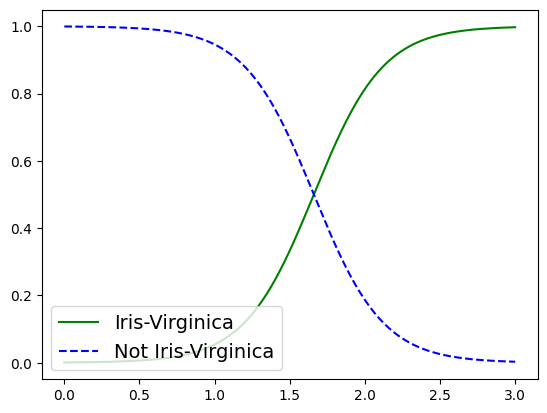

In [36]:
X_new = np.linspace(0,3,1000).reshape(-1,1)
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:,1], "g-", label="Iris-Virginica")
plt.plot(X_new,y_proba[:,0],'b--', label="Not Iris-Virginica")
plt.legend(loc="lower left", fontsize=14)

In [37]:
log_reg.predict([[1.7],[1.5]])

array([1, 0])

## Softmax回归

 **Softmax 回归（Softmax Regression）**，也称为**多元逻辑回归（Multinomial Logistic Regression）**

它允许模型直接支持多个类别，而不需要训练多个二元分类器。

---

### 1. 核心原理：从单一分数到多类概率

Softmax 回归的工作流程分为两步：

1. **计算得分**：对于给定的实例 $\mathbf{x}$，模型先计算每个类别 $k$ 的得分 $s_k(\mathbf{x})$（这本质上还是线性回归的加权和）。
2. **转换为概率**：通过 **Softmax 函数** 对所有得分进行归一化处理，使得所有类别的预测概率之和等于 1。

#### Softmax 函数公式：

$$\hat{p}_k = \sigma(\mathbf{s}(\mathbf{x}))_k = \frac{\exp(s_k(\mathbf{x}))}{\sum_{j=1}^{K} \exp(s_j(\mathbf{x}))}$$

---

### 2. 预测逻辑：胜者全拿 (Winner-Take-All)

在预测时，Softmax 回归模型会选择估算概率最高的那个类别作为预测结果。

* **重要限制**：Softmax 回归是**互斥**的。这意味着它只能从多个类中选出**一个**（例如：区分它是哪一种鸢尾花），而不能在一个实例中识别出多个类别（例如：一张图里既有猫又有狗）。

---

### 3. 训练与损失函数：交叉熵 (Cross Entropy)

为了衡量预测概率分布与真实标签之间的差距，Softmax 回归使用**交叉熵损失函数**。

* **原理**：如果模型对目标类别的预测概率很低，交叉熵就会很高。
* **优势**：它能有效惩罚那些“自信地预测错误”的模型，使得梯度下降能更快地调整参数。

---

### 代码实践：三分类鸢尾花

在 Scikit-Learn 中，`LogisticRegression` 默认会根据数据的类别数量自动切换到 Softmax 回归（或者你可以显式指定 `multi_class="multinomial"`）。


---

### 知识点笔记：逻辑回归 vs Softmax 回归

| 特性 | 逻辑回归 (Logistic) | Softmax 回归 |
| --- | --- | --- |
| **分类数量** | 二元分类 (Binary) | 多元分类 (Multiclass) |
| **输出形式** | 单个概率 (属于正类的概率) | 概率分布向量 (所有类概率和为 1) |
| **关系** | Softmax 在类别数为 2 时的特例 | 逻辑回归的泛化形式 |

---


In [39]:
X = iris['data'][:,(2,3)]
y = iris['target']

softmax_reg = LogisticRegression(multi_class='multinomial',solver='lbfgs',C = 10)
softmax_reg.fit(X, y)

C:\Users\24677\PycharmProjects\Hands-On_Machine_Learning_with_Scikit_Learn&TensorFlow\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [40]:
softmax_reg.predict([[5,2]])

array([2])

In [42]:
softmax_reg.predict_proba([[5,2]])

array([[6.21626370e-07, 5.73689802e-02, 9.42630398e-01]])

### 章节总结

第四章《训练模型》的所有核心内容：

1. **线性回归**：从标准方程到各类梯度下降（批量、随机、小批量）。
2. **多项式回归**：处理非线性关系。
3. **正则化**：岭回归、套索、弹性网络、早期停止法。
4. **逻辑回归与 Softmax**：从预测数值跨越到概率分类。